In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

import os
import sys
os.chdir("..")

df_listings = pd.read_csv('data/combined_csvs/listings_property_vals.csv')
df_future = pd.read_csv('data/combined_csvs/future_rates.csv')
df_past = pd.read_csv('data/combined_csvs/past_rates.csv')
df_reviews = pd.read_csv('data/combined_csvs/reviews.csv')

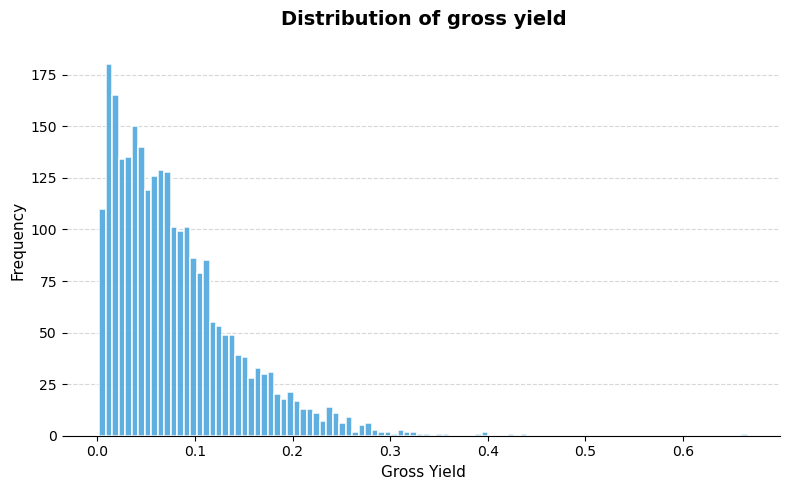

In [2]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    df_listings["gross_yield"],
    bins=100,
    color="#4EA8DE",
    edgecolor="white",
    linewidth=1.2,
    alpha=0.9,
)

ax.set_title("Distribution of gross yield", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Gross Yield", fontsize=11)
ax.set_ylabel("Frequency", fontsize=11)

ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

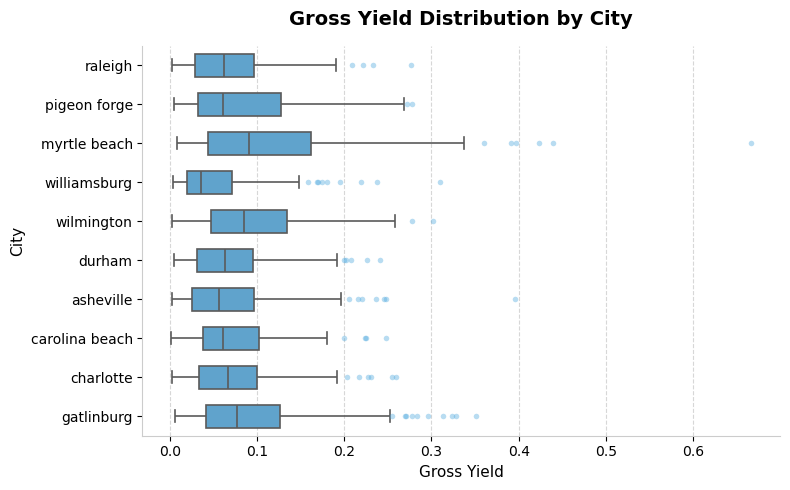

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))

# flierprops styles the outlier points to keep them clean and subtle
sns.boxplot(
    data=df_listings,
    x="gross_yield",
    y="city",
    ax=ax,
    color="#4EA8DE",
    width=0.6,
    linewidth=1.2,
    flierprops={
        "marker": "o",
        "markersize": 4,
        "markerfacecolor": "#4EA8DE",
        "markeredgecolor": "none",
        "alpha": 0.4,
    },
)

ax.set_title(
    "Gross Yield Distribution by City", fontsize=14, fontweight="bold", pad=15
)
ax.set_xlabel("Gross Yield", fontsize=11)
ax.set_ylabel("City", fontsize=11)

ax.grid(axis="x", linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#cccccc")
ax.spines["bottom"].set_color("#cccccc")

plt.tight_layout()
plt.show()

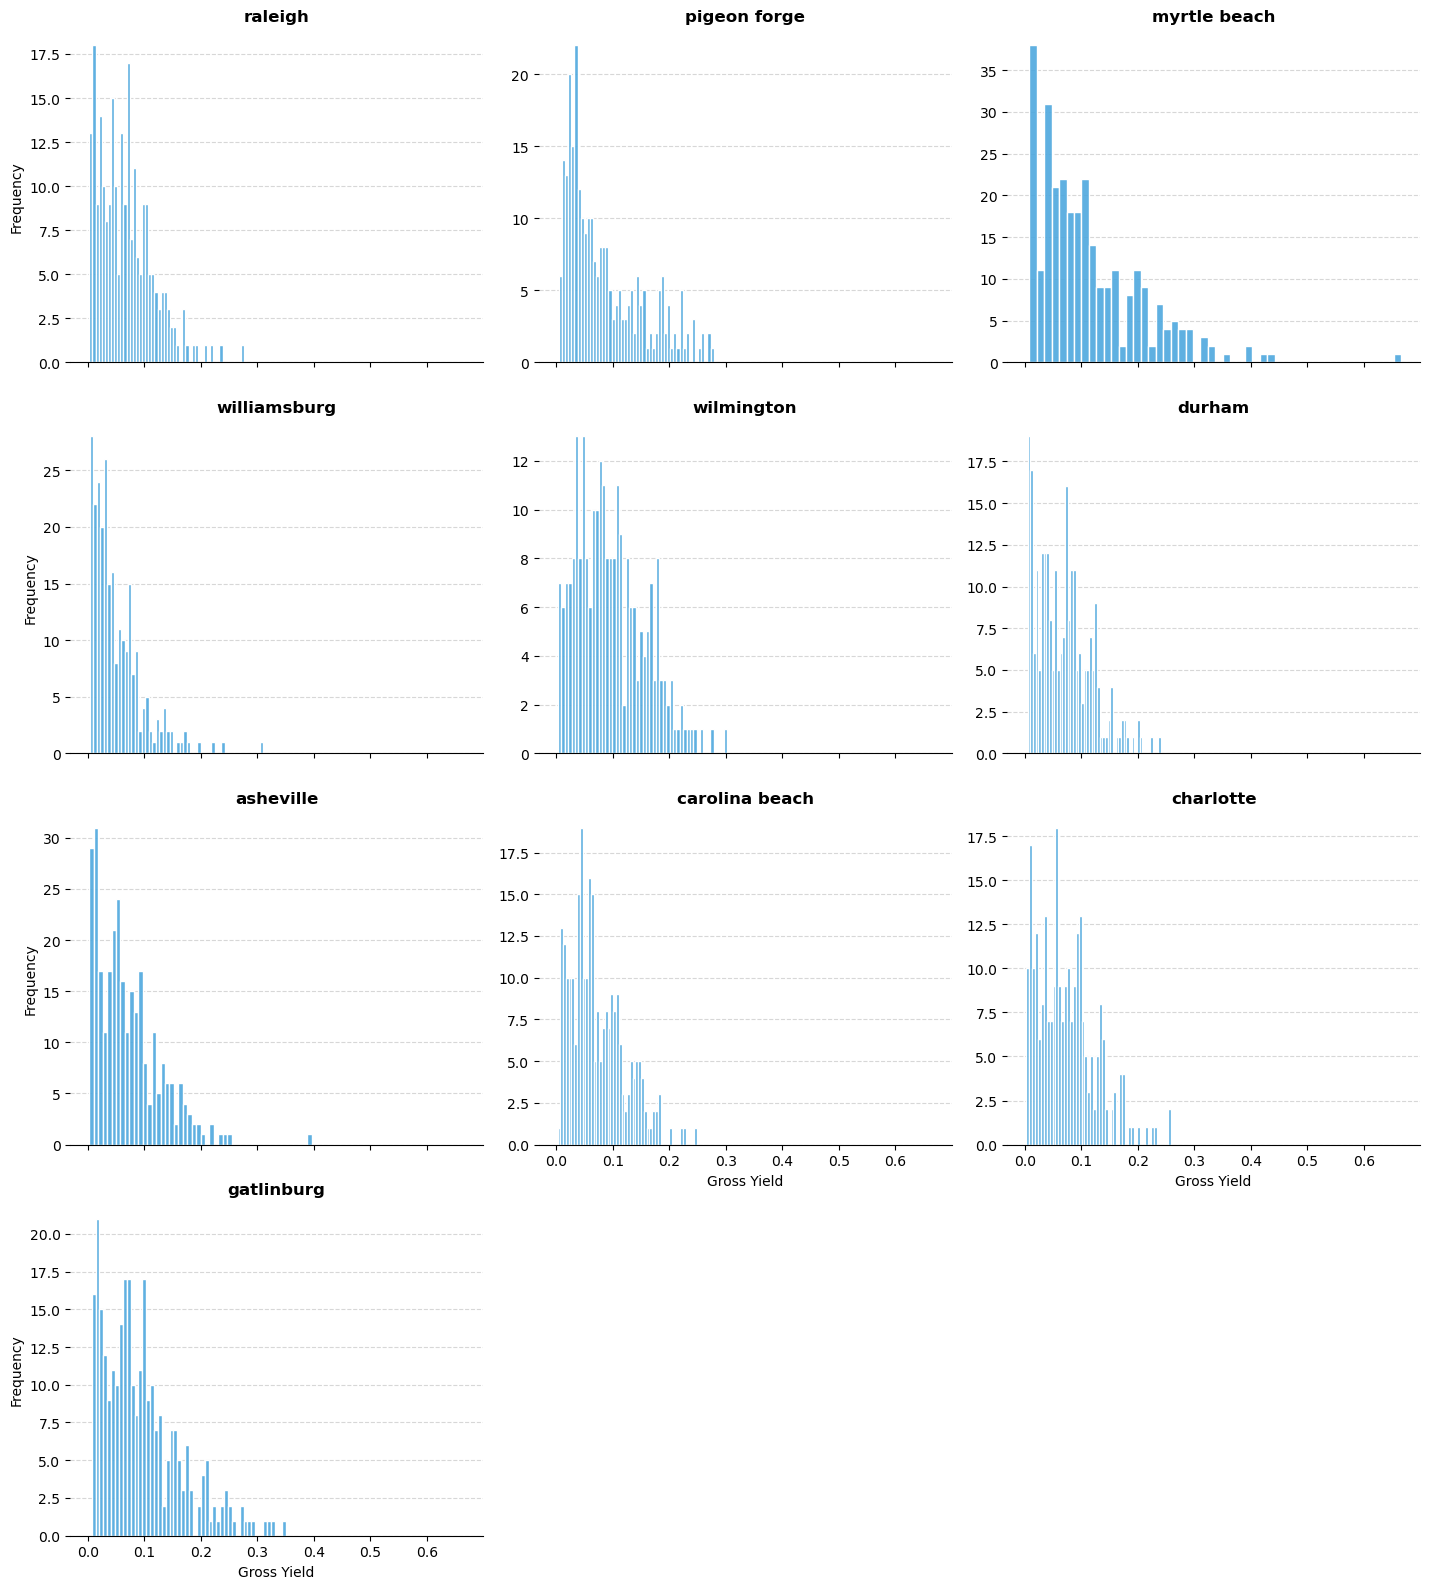

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# This automatically creates a grid of plots based on the number of unique cities
g = sns.FacetGrid(
    df_listings, col="city", col_wrap=3, height=4, aspect=1.2, sharey=False
)

g.map_dataframe(
    sns.histplot,
    x="gross_yield",
    bins=50,
    color="#4EA8DE",
    edgecolor="white",
    linewidth=1,
    alpha=0.9,
)

g.set_titles(col_template="{col_name}", size=12, weight="bold")
g.set_axis_labels("Gross Yield", "Frequency")

for ax in g.axes.flat:
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

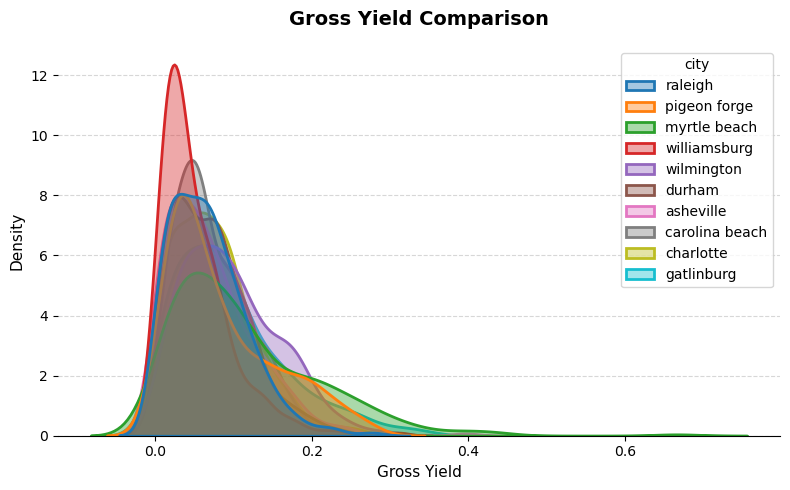

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

sns.kdeplot(
    data=df_listings,
    x="gross_yield",
    hue="city",
    fill=True,
    common_norm=False,
    alpha=0.4,
    linewidth=2,
    ax=ax,
)

ax.set_title(
    "Gross Yield Comparison", fontsize=14, fontweight="bold", pad=15
)
ax.set_xlabel("Gross Yield", fontsize=11)
ax.set_ylabel("Density", fontsize=11)

ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

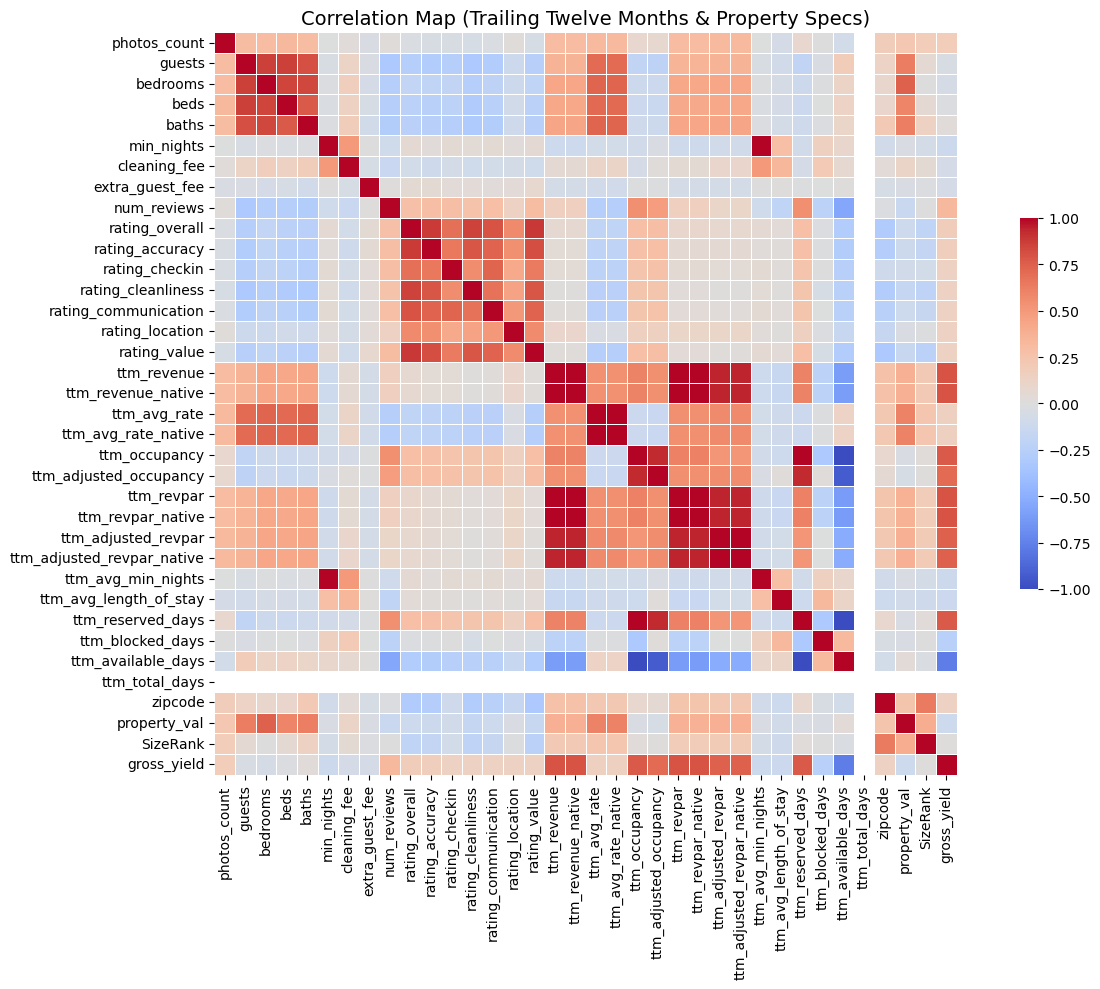

In [6]:
# Assuming your dataframe is named 'df'
# 1. Drop any columns that start with 'l90d_'
filtered_df = df_listings.loc[
    :, ~df_listings.columns.str.startswith("l90d_")
]  # Handles both 'l90d_' and 'l90_' patterns

# 2. Select only numeric columns
numeric_df = filtered_df.select_dtypes(include=["number"])

# 3. Drop unhelpful numeric identifiers/coordinates
cols_to_drop = ["listing_id", "host_id", "latitude", "longitude"]
numeric_df = numeric_df.drop(
    columns=[col for col in cols_to_drop if col in numeric_df.columns]
)

# 4. Calculate correlation matrix
corr_matrix = numeric_df.corr()

# 5. Plot the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    vmax=1,
    vmin=-1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=False,  # Set to True if you want the exact correlation numbers visible
    fmt=".2f",
)

plt.title("Correlation Map (Trailing Twelve Months & Property Specs)", fontsize=14)
plt.tight_layout()
plt.show()

/var/folders/gm/dyt9t75x0kn2y9njgtrx0ddr0000gn/T/ipykernel_13487/658026086.py:46: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


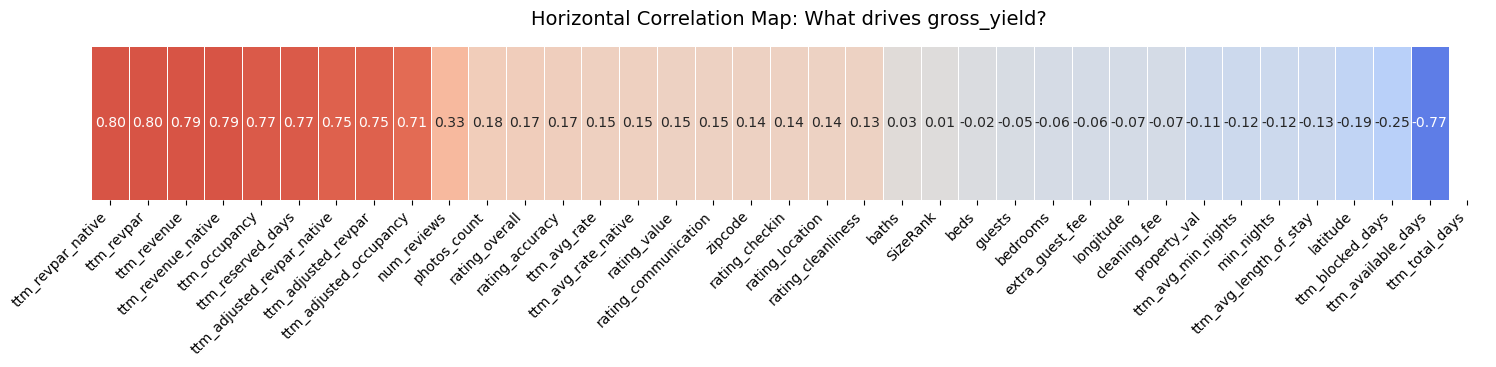

In [7]:
# 1. Filter out l90d_ columns and keep only numbers
filtered_df = df_listings.loc[:, ~df_listings.columns.str.startswith("l90d_")]
numeric_df = filtered_df.select_dtypes(include=["number"])

# Drop ID and coordinate columns
cols_to_drop = ["listing_id", "host_id"]
numeric_df = numeric_df.drop(
    columns=[col for col in cols_to_drop if col in numeric_df.columns]
)

# 2. Pick your target metric
target_metric = "gross_yield"

# 3. Calculate correlation and isolate the target row
# Sort values so the strongest correlations are grouped together
target_corr = (
    numeric_df.corr()[[target_metric]]
    .drop(index=target_metric)
    .sort_values(by=target_metric, ascending=False)
)

# Transpose it to make it horizontal (1 row, N columns)
target_corr_horizontal = target_corr.T

# 4. Plot the horizontal strip
plt.figure(figsize=(18, 2))  # Wide and short shape
sns.heatmap(
    target_corr_horizontal,
    cmap="coolwarm",
    vmax=1,
    vmin=-1,
    center=0,
    annot=True,  # Shows the correlation numbers
    fmt=".2f",
    cbar=False,  # Hide colorbar to save horizontal space
    linewidths=0.5,
)

plt.title(
    f"Horizontal Correlation Map: What drives {target_metric}?",
    fontsize=14,
    pad=15,
)
plt.yticks([])  # Hide the single row label for a cleaner look
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

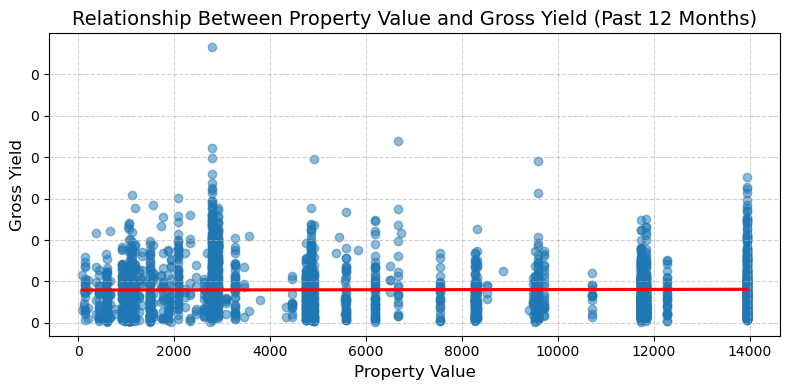

In [8]:
# Assuming your dataframe is named 'df'
plt.figure(figsize=(8, 4))

# sns.regplot draws the scatter points and fits a linear regression line
sns.regplot(
    data=df_listings,
    x="SizeRank",
    y="gross_yield",
    scatter_kws={"alpha": 0.5, "color": "#1f77b4"},
    line_kws={"color": "red"},
)

# Format axes nicely
plt.title(
    "Relationship Between Property Value and Gross Yield (Past 12 Months)", fontsize=14
)
plt.xlabel("Property Value", fontsize=12)
plt.ylabel("Gross Yield", fontsize=12)

# If your revenue numbers are large, this formats the Y-axis with commas (e.g., 50,000)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [9]:
categorical_cols = filtered_df.select_dtypes(include=["object", "category", "str"]).columns

In [10]:
categorical_cols

Index(['listing_name', 'description', 'listing_type', 'room_type',
       'cover_photo_url', 'photo_urls', 'host_name', 'cohost_ids',
       'cohost_names', 'amenities', 'instant_book', 'professional_management',
       'cancellation_policy', 'checkin_time', 'checkout_time',
       'guest_favorite', 'exact_location', 'currency', 'single_fee_structure',
       'city', 'Geocodio Address Line 1'],
      dtype='str')

/var/folders/gm/dyt9t75x0kn2y9njgtrx0ddr0000gn/T/ipykernel_13487/3917280845.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


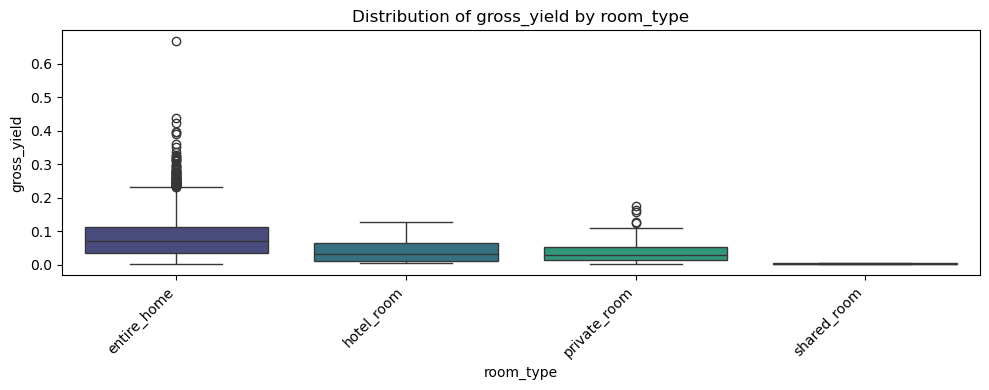

/var/folders/gm/dyt9t75x0kn2y9njgtrx0ddr0000gn/T/ipykernel_13487/3917280845.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


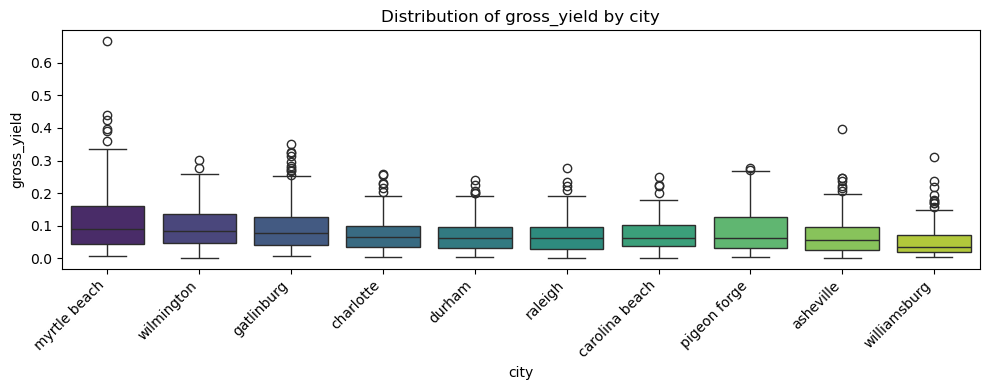

/var/folders/gm/dyt9t75x0kn2y9njgtrx0ddr0000gn/T/ipykernel_13487/3917280845.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


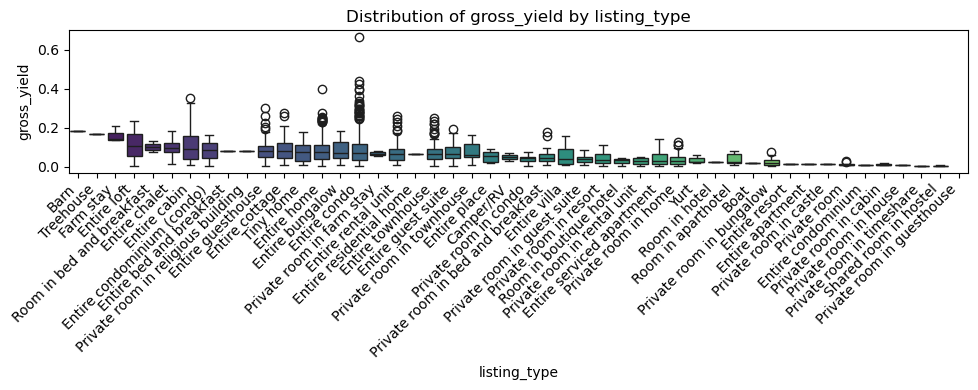

In [11]:
for col in ["room_type", "city", "listing_type"]:  
    plt.figure(figsize=(10, 4))
    
    # Sort categories by median yield for a cleaner plot
    order = filtered_df.groupby(col)[target_metric].median().sort_values(ascending=False).index
    
    sns.boxplot(
        data=filtered_df, 
        x=col, 
        y=target_metric, 
        order=order,
        palette="viridis"
    )
    plt.title(f"Distribution of {target_metric} by {col}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

In [14]:
pd.set_option('display.max_columns', None)
df_listings[pd.isna(df_listings["gross_yield"])]

,listing_id,listing_name,description,listing_type,room_type,cover_photo_url,photos_count,photo_urls,host_id,host_name,cohost_ids,cohost_names,superhost,latitude,longitude,guests,bedrooms,beds,baths,registration,amenities,instant_book,professional_management,min_nights,cancellation_policy,checkin_time,checkout_time,guest_favorite,exact_location,currency,cleaning_fee,extra_guest_fee,single_fee_structure,num_reviews,rating_overall,rating_accuracy,rating_checkin,rating_cleanliness,rating_communication,rating_location,rating_value,ttm_revenue,ttm_revenue_native,ttm_avg_rate,ttm_avg_rate_native,ttm_occupancy,ttm_adjusted_occupancy,ttm_revpar,ttm_revpar_native,ttm_adjusted_revpar,ttm_adjusted_revpar_native,ttm_avg_min_nights,ttm_avg_length_of_stay,ttm_reserved_days,ttm_blocked_days,ttm_available_days,ttm_total_days,l90d_revenue,l90d_revenue_native,l90d_avg_rate,l90d_avg_rate_native,l90d_occupancy,l90d_adjusted_occupancy,l90d_revpar,l90d_revpar_native,l90d_adjusted_revpar,l90d_adjusted_revpar_native,l90d_avg_min_nights,l90d_avg_length_of_stay,l90d_reserved_days,l90d_blocked_days,l90d_available_days,l90d_total_days,city,Geocodio Address Line 1,zipcode,property_val,SizeRank,gross_yield
0,318749,Suite near NC State & downtown,"Enjoy convenient, comfortable and private acco...",Private room in home,private_room,https://a0.muscache.com/im/pictures/miso/Hosti...,8.0,https://a0.muscache.com/im/pictures/miso/Hosti...,1635860,Deborah,NaN,NaN,False,35.7952,-78.6728,NaN,1.0,1.0,0.0,False,"Hair dryer,Body soap,Hot water,Essentials,Hang...",False,False,4.0,Moderate,3:00 PM,11:00 AM,True,False,USD,55.0,5.0,False,73.0,4.84,4.9,4.9,4.9,4.9,4.9,4.9,3074.0,3074.0,67.7,67.7,0.107,0.165,7.5,7.5,11.6,11.6,4.0,2.3,39,128,326,365,922.0,922.0,64.5,64.5,0.122,0.122,9.0,9.0,9.0,9.0,4.0,2.8,11,0,79,90,raleigh,2729 Van Dyke Ave,27607,NaN,NaN,NaN
5,1144274,Quiet Lake House with Private Room and Bath,"The house is full of interesting, eclectic art...",Private room in home,private_room,https://a0.muscache.com/im/pictures/miso/Hosti...,11.0,https://a0.muscache.com/im/pictures/miso/Hosti...,6273893,Barbara,NaN,NaN,False,35.8983,-78.7117,NaN,1.0,2.0,0.0,False,"Free parking on premises,Hair dryer,Shampoo,Co...",NaN,False,2.0,Moderate,4:00 PM,11:00 AM,True,False,USD,25.0,10.0,True,72.0,4.83,4.8,4.9,4.8,4.9,4.9,4.8,10249.0,10249.0,71.3,71.3,0.375,0.377,26.9,26.9,27.1,27.1,2.0,7.6,137,2,228,365,1951.0,1951.0,74.3,74.3,0.256,0.256,19.7,19.7,19.7,19.7,2.0,3.3,23,0,67,90,raleigh,8608 Lakewood Dr,27613,NaN,NaN,NaN
15,5646287,Adorable 1BR studio in Five Points,This is one half of a renovated 1940's era dup...,Entire guesthouse,entire_home,https://a0.muscache.com/im/pictures/596897eb-9...,12.0,https://a0.muscache.com/im/pictures/596897eb-9...,29238567,Matthew,39379534,Hilary,True,35.8051,-78.6264,2.0,1.0,1.0,1.0,True,"Hair dryer,Cleaning products,Shampoo,Condition...",NaN,False,1.0,Moderate,3:00 PM,11:00 AM,True,True,USD,40.0,0.0,True,501.0,4.88,4.9,5.0,4.8,5.0,4.9,4.9,22803.0,22803.0,110.9,110.9,0.518,0.573,58.1,58.1,64.3,64.3,1.1,4.1,189,35,176,365,3347.0,3347.0,128.5,128.5,0.256,0.418,34.5,34.5,56.5,56.5,1.0,2.9,23,35,67,90,raleigh,721 Georgetown Rd,27608,NaN,NaN,NaN
17,6277096,"Peaceful Getaway-private master suite, pool, pond",Enjoy spacious private guestroom with a king-s...,Private room in home,private_room,https://a0.muscache.com/im/pictures/hosting/Ho...,37.0,https://a0.muscache.com/im/pictures/hosting/Ho...,32627001,Sandy,NaN,NaN,True,35.8728,-78.4918,NaN,1.0,3.0,0.0,False,"Bathtub,Hair dryer,Cleaning products,Shampoo,C...",NaN,False,1.0,Flexible,3:00 PM,11:00 AM,True,False,USD,30.0,0.0,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7000.0,7000.0,106.5,106.5,0.189,0.189,18.8,18.8,18.8,18.8,1.3,8.6,69,0,296,365,0.0,0.0,125.6,125.6,0.000,0.000,0.0,0.0,0.0,0.0,1.3,0.0,0,0,90,90,raleigh,3124 McDade Farm Rd,27616,NaN,NaN,NaN
18,6557236,Convenient North Raleigh location.,Contemporary condo in convenient North Raleigh...,Entire rental unit,entire_home,https://a0.muscache.com/im/pictur